In [1]:
pip install wfdb

Note: you may need to restart the kernel to use updated packages.


## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import wfdb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


2026-01-12 12:08:25.987980: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768219706.010031     277 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768219706.017120     277 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768219706.035273     277 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768219706.035298     277 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768219706.035301     277 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load Preprocessed Data

In [ ]:
DATASET_PATH = '/kaggle/input/ecg-processed-dataset'

signals = np.load(f"{DATASET_PATH}/windowed_signals_9000.npy")
meta = pd.read_csv(f"{DATASET_PATH}/windowed_metadata.csv")

meta["signal"] = list(signals)
windowed_df = meta

label_encoding = {
    "N": 0,
    "A": 1,
    "O": 2,
    "~": 3
}

windowed_df["label_id"] = windowed_df["label"].map(label_encoding)

X = np.stack(windowed_df["signal"].values)
y = windowed_df["label_id"].values

# Add channel dimension for Conv1D
X = X[..., np.newaxis]

print("Data shape:", X.shape)  # (num_windows, 9000, 1)
print("Labels shape:", y.shape)
print("\nClass distribution:")
print(Counter(y))


Data shape: (9376, 9000, 1)
Labels shape: (9376,)

Class distribution:
Counter({np.int64(0): 5458, np.int64(2): 2797, np.int64(1): 831, np.int64(3): 290})


## Train-Test Split

In [ ]:
record_labels = (
    windowed_df
    .groupby("record_id")["label_id"]
    .first()
)

train_records, val_records = train_test_split(
    record_labels.index.values,
    test_size=0.2,
    random_state=42,
    stratify=record_labels.values
)

train_idx = windowed_df["record_id"].isin(train_records)
val_idx = windowed_df["record_id"].isin(val_records)

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

print(f"\nTrain size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"\nTrain class distribution: {Counter(y_train)}")
print(f"Val class distribution: {Counter(y_val)}")


Train size: 7510
Validation size: 1866

Train class distribution: Counter({np.int64(0): 4368, np.int64(2): 2241, np.int64(1): 670, np.int64(3): 231})
Val class distribution: Counter({np.int64(0): 1090, np.int64(2): 556, np.int64(1): 161, np.int64(3): 59})


## Class Weights for Imbalanced Data

In [ ]:
all_classes = np.array([0, 1, 2, 3])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=all_classes,
    y=y_train
)

class_weight_dict = dict(zip(all_classes, class_weights))
print("\nClass weights:")
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.4f}")


Class weights:
  Class 0: 0.4298
  Class 1: 2.8022
  Class 2: 0.8378
  Class 3: 8.1277


## Generate Spectrograms using FFT

Computing spectrograms for training data...


I0000 00:00:1768219709.426633     277 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Computing spectrograms for validation data...

Train spectrogram shape: (7510, 69, 129, 1)
Val spectrogram shape: (1866, 69, 129, 1)


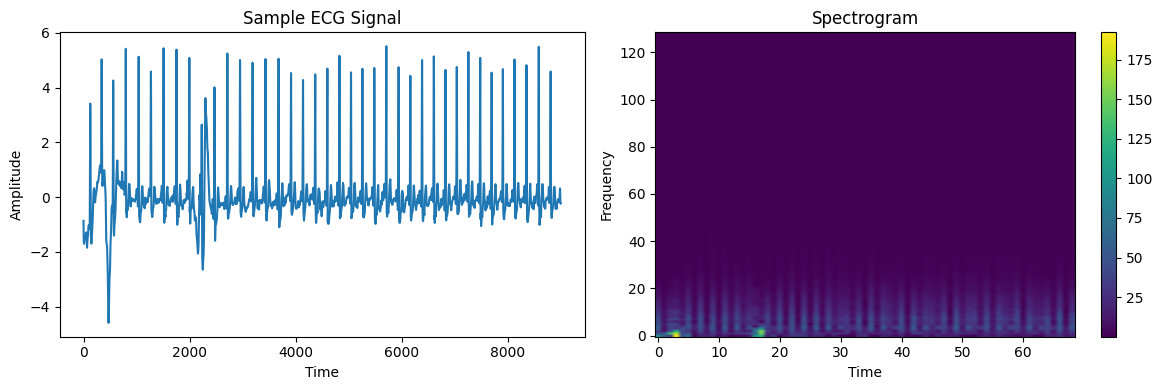

In [ ]:
def compute_spectrogram(signal, n_fft=256, hop_length=128):
    """
    Compute spectrogram using Short-Time Fourier Transform (STFT)

    Args:
        signal: 1D ECG signal
        n_fft: FFT window size
        hop_length: Number of samples between successive frames

    Returns:
        Spectrogram magnitude (2D array)
    """
    
    stft = tf.signal.stft(
        signal,
        frame_length=n_fft,
        frame_step=hop_length,
        fft_length=n_fft
    )

    spectrogram = tf.abs(stft)

    return spectrogram.numpy()

print("Computing spectrograms for training data...")
X_train_spec = np.array([compute_spectrogram(sig.squeeze()) for sig in X_train])
print("Computing spectrograms for validation data...")
X_val_spec = np.array([compute_spectrogram(sig.squeeze()) for sig in X_val])

# Add channel dimension for Conv2D
X_train_spec = X_train_spec[..., np.newaxis]
X_val_spec = X_val_spec[..., np.newaxis]

print(f"\nTrain spectrogram shape: {X_train_spec.shape}")
print(f"Val spectrogram shape: {X_val_spec.shape}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(X_train[0].squeeze())
plt.title("Sample ECG Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.subplot(1, 2, 2)
plt.imshow(X_train_spec[0].squeeze().T, aspect='auto', origin='lower', cmap='viridis')
plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar()
plt.tight_layout()
plt.show()

## Define TCN Components

In [ ]:
class WeightNormalization(layers.Wrapper):
    """Weight normalization layer"""
    def __init__(self, layer, **kwargs):
        super(WeightNormalization, self).__init__(layer, **kwargs)

    def build(self, input_shape):
        self.layer.build(input_shape)
        self.built = True

    def call(self, inputs):
        return self.layer(inputs)

def temporal_block(x, dilation_rate, nb_filters, kernel_size, dropout_rate=0.2):
    """
    Temporal Block for TCN

    Args:
        x: Input tensor
        dilation_rate: Dilation rate for causal convolution
        nb_filters: Number of filters
        kernel_size: Kernel size
        dropout_rate: Dropout rate

    Returns:
        Output tensor
    """
    # First conv layer
    conv1 = layers.Conv1D(
        filters=nb_filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding='causal',
        activation=None
    )(x)
    conv1 = layers.PReLU()(conv1)
    conv1 = layers.Dropout(dropout_rate)(conv1)

    # Second conv layer
    conv2 = layers.Conv1D(
        filters=nb_filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding='causal',
        activation=None
    )(conv1)
    conv2 = layers.PReLU()(conv2)
    conv2 = layers.Dropout(dropout_rate)(conv2)

    # Residual connection
    if x.shape[-1] != nb_filters:
        residual = layers.Conv1D(filters=nb_filters, kernel_size=1, padding='same')(x)
    else:
        residual = x

    output = layers.Add()([conv2, residual])
    output = layers.PReLU()(output)

    return output

def squeeze_excite_block(x, ratio=8):
    """
    Squeeze-and-Excitation block for channel attention

    Args:
        x: Input tensor
        ratio: Reduction ratio

    Returns:
        Output tensor with channel attention applied
    """
    channels = x.shape[-1]

    # Squeeze
    se = layers.GlobalAveragePooling1D()(x)

    # Excitation
    se = layers.Dense(channels // ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)

    # Scale
    se = layers.Reshape((1, channels))(se)
    output = layers.Multiply()([x, se])

    return output


### Build TCN Module

In [ ]:
def build_tcn_module(input_shape=(9000, 1)):
    """
    Build TCN module for temporal feature extraction

    Args:
        input_shape: Shape of input ECG signal

    Returns:
        TCN model
    """
    inputs = layers.Input(shape=input_shape)

    # Temporal Block 1 (dilation=1, filters=128)
    x = temporal_block(inputs, dilation_rate=1, nb_filters=128, kernel_size=9)

    # Temporal Block 2 (dilation=2, filters=256)
    x = temporal_block(x, dilation_rate=2, nb_filters=256, kernel_size=9)

    # Temporal Block 3 (dilation=4, filters=512)
    x = temporal_block(x, dilation_rate=4, nb_filters=512, kernel_size=9)

    # Temporal Block 4 (dilation=8, filters=1024)
    x = temporal_block(x, dilation_rate=8, nb_filters=1024, kernel_size=9)

    # Squeeze-and-Excitation Block
    x = squeeze_excite_block(x, ratio=8)

    # Global pooling to get temporal features
    x = layers.GlobalAveragePooling1D()(x)

    model = Model(inputs=inputs, outputs=x, name='TCN_Module')

    return model

# Build and display TCN module
tcn_module = build_tcn_module()
print("\n" + "="*50)
print("TCN MODULE ARCHITECTURE")
print("="*50)
tcn_module.summary()


TCN MODULE ARCHITECTURE


Model: "TCN_Module"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 9000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 9000, 128) │      1,280 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu (PReLU)     │ (None, 9000, 128) │  1,152,000 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 9000, 128) │          0 │ p_re_lu[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 9000, 128) │    147,584 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_1 (PReLU)   │ (None, 9000, 128) │  1,152,000 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 9000, 128) │          0 │ p_re_lu_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 9000, 128) │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 9000, 128) │          0 │ dropout_1[0][0],  │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_2 (PReLU)   │ (None, 9000, 128) │  1,152,000 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 9000, 256) │    295,168 │ p_re_lu_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_3 (PReLU)   │ (None, 9000, 256) │  2,304,000 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 9000, 256) │          0 │ p_re_lu_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 9000, 256) │    590,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_4 (PReLU)   │ (None, 9000, 256) │  2,304,000 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 9000, 256) │          0 │ p_re_lu_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 9000, 256) │     33,024 │ p_re_lu_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 9000, 256) │          0 │ dropout_3[0][0],  │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_5 (PReLU)   │ (None, 9000, 256) │  2,304,000 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 9000, 512) │  1,180,160 │ p_re_lu_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_6 (PReLU)   │ (None, 9000, 512) │  4,608,000 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 9000, 512) │          0 │ p_re_lu_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 9000, 512) │  2,359,808 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 71,525,376 (272.85 MB)

 Trainable params: 71,525,376 (272.85 MB)

 Non-trainable params: 0 (0.00 B)

### Build ResNet Module

In [ ]:
def residual_block_2d(x, filters, kernel_size=(3, 3), dropout_rate=0.2):
    """
    Residual block for 2D convolutions (for spectrograms)

    Args:
        x: Input tensor
        filters: Number of filters
        kernel_size: Kernel size
        dropout_rate: Dropout rate

    Returns:
        Output tensor
    """
    # First conv layer
    conv1 = layers.Conv2D(filters, kernel_size, padding='same')(x)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.PReLU()(conv1)
    conv1 = layers.Dropout(dropout_rate)(conv1)

    # Second conv layer
    conv2 = layers.Conv2D(filters, kernel_size, padding='same')(conv1)
    conv2 = layers.BatchNormalization()(conv2)

    # Residual connection
    if x.shape[-1] != filters:
        residual = layers.Conv2D(filters, (1, 1), padding='same')(x)
        residual = layers.BatchNormalization()(residual)
    else:
        residual = x

    output = layers.Add()([conv2, residual])
    output = layers.PReLU()(output)

    return output

def build_resnet_module(input_shape):
    """
    Build ResNet module for spectral feature extraction

    Args:
        input_shape: Shape of input spectrogram

    Returns:
        ResNet model
    """
    inputs = layers.Input(shape=input_shape)

    # ResBlock 1 (filters=128)
    x = residual_block_2d(inputs, filters=128)
    x = layers.AveragePooling2D(pool_size=(2, 2))(x)

    # ResBlock 2 (filters=256)
    x = residual_block_2d(x, filters=256)
    x = layers.AveragePooling2D(pool_size=(2, 2))(x)

    # ResBlock 3 (filters=512)
    x = residual_block_2d(x, filters=512)
    x = layers.AveragePooling2D(pool_size=(2, 2))(x)

    # ResBlock 4 (filters=512)
    x = residual_block_2d(x, filters=512)
    x = layers.AveragePooling2D(pool_size=(2, 2))(x)

    # ResBlock 5 (filters=256)
    x = residual_block_2d(x, filters=256)

    # Global pooling to get spectral features
    x = layers.GlobalAveragePooling2D()(x)

    model = Model(inputs=inputs, outputs=x, name='ResNet_Module')

    return model

# Build and display ResNet module
resnet_module = build_resnet_module(X_train_spec.shape[1:])
print("\n" + "="*50)
print("RESNET MODULE ARCHITECTURE")
print("="*50)
resnet_module.summary()


RESNET MODULE ARCHITECTURE


Model: "ResNet_Module"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 69, 129,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 69, 129,   │      1,280 │ input_layer_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 69, 129,   │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_12 (PReLU)  │ (None, 69, 129,   │  1,139,328 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 69, 129,   │          0 │ p_re_lu_12[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 69, 129,   │    147,584 │ dropout_8[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 69, 129,   │        256 │ input_layer_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 69, 129,   │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 69, 129,   │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 69, 129,   │          0 │ batch_normalizat… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_13 (PReLU)  │ (None, 69, 129,   │  1,139,328 │ add_4[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 34, 64,    │          0 │ p_re_lu_13[0][0]  │
│ (AveragePooling2D)  │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 34, 64,    │    295,168 │ average_pooling2… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 34, 64,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_14 (PReLU)  │ (None, 34, 64,    │    557,056 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 34, 64,    │          0 │ p_re_lu_14[0][0]  │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 34, 64,    │    590,080 │ dropout_9[0][0] 

 Total params: 15,475,072 (59.03 MB)

 Trainable params: 15,466,112 (59.00 MB)

 Non-trainable params: 8,960 (35.00 KB)

### Build Combined TCN-ResNet Model


COMBINED TCN-RESNET MODEL


Model: "TCN_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ signal_input        │ (None, 9000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spec_input          │ (None, 69, 129,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ TCN_Module          │ (None, 1024)      │ 71,525,376 │ signal_input[0][… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ResNet_Module       │ (None, 256)       │ 15,475,072 │ spec_input[0][0]  │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1280)      │          0 │ TCN_Module[0][0], │
│ (Concatenate)       │                   │            │ ResNet_Module[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │    655,872 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 512)       │          0 │ dense_4[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    131,328 │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 256)       │          0 │ dense_5[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4)         │      1,028 │ dropout_27[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 87,788,676 (334.89 MB)

 Trainable params: 87,779,716 (334.85 MB)

 Non-trainable params: 8,960 (35.00 KB)

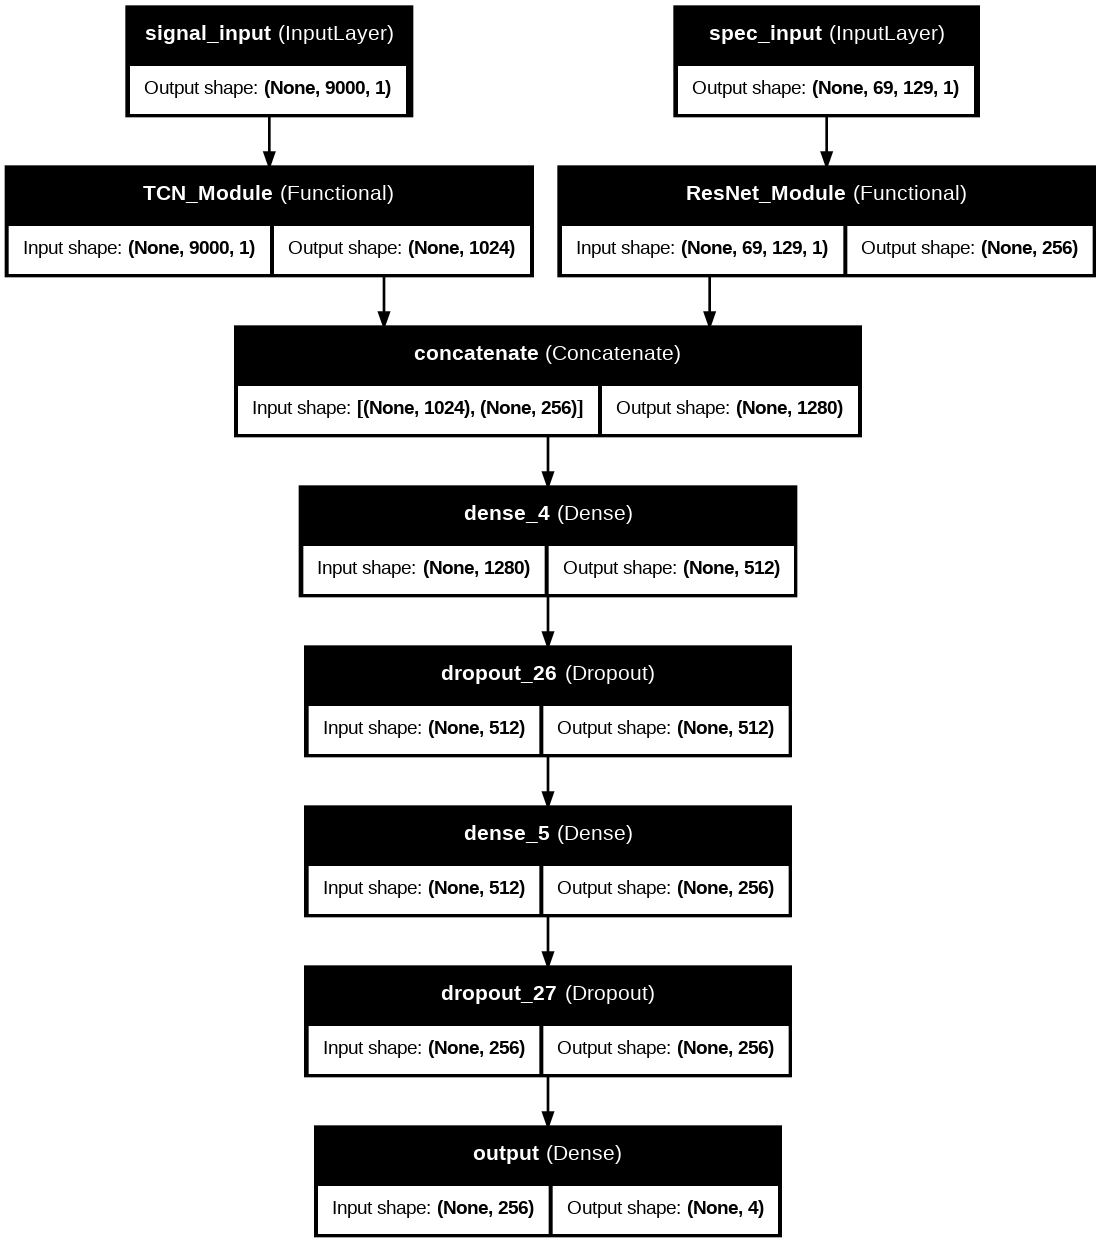

In [ ]:
def build_tcn_resnet_model(signal_shape=(9000, 1), spec_shape=None, num_classes=4):
    """
    Build combined TCN-ResNet model

    Args:
        signal_shape: Shape of ECG signal input
        spec_shape: Shape of spectrogram input
        num_classes: Number of output classes

    Returns:
        Combined model
    """
    # TCN branch (temporal features)
    signal_input = layers.Input(shape=signal_shape, name='signal_input')
    tcn_features = build_tcn_module(signal_shape)(signal_input)

    # ResNet branch (spectral features)
    spec_input = layers.Input(shape=spec_shape, name='spec_input')
    resnet_features = build_resnet_module(spec_shape)(spec_input)

    # Concatenate features
    combined = layers.Concatenate()([tcn_features, resnet_features])

    # Classification head
    x = layers.Dense(512, activation='relu')(combined)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    # Create model
    model = Model(
        inputs=[signal_input, spec_input],
        outputs=outputs,
        name='TCN_ResNet'
    )

    return model

# Build combined model
combined_model = build_tcn_resnet_model(
    signal_shape=(9000, 1),
    spec_shape=X_train_spec.shape[1:],
    num_classes=4
)

print("\n" + "="*50)
print("COMBINED TCN-RESNET MODEL")
print("="*50)
combined_model.summary()

# Plot model architecture
tf.keras.utils.plot_model(
    combined_model,
    to_file='tcn_resnet_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    dpi=96
)

### Compile Model

In [ ]:
# Custom weighted categorical crossentropy
def weighted_categorical_crossentropy(weights):
    """
    Weighted categorical crossentropy loss
    """
    weights = tf.constant(weights, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        loss = -tf.reduce_sum(y_true * tf.math.log(y_pred) * weights, axis=-1)
        return loss

    return loss

# Prepare class weights for loss function
loss_weights = [class_weight_dict[i] for i in range(4)]

# Compile model
combined_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss=weighted_categorical_crossentropy(loss_weights),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("\nModel compiled successfully!")


Model compiled successfully!


In [ ]:
# Setup Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_tcn_resnet_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured:")
for cb in callbacks:
    print(f"  - {cb.__class__.__name__}")

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - ModelCheckpoint


In [13]:
import warnings
warnings.filterwarnings("ignore")

### Train Combined TCN-ResNet Model

In [ ]:
# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes=4)
y_val_cat = to_categorical(y_val, num_classes=4)

print("\nStarting training...")
print("="*50)

history_combined = combined_model.fit(
    [X_train, X_train_spec],
    y_train_cat,
    validation_data=([X_val, X_val_spec], y_val_cat),
    epochs=50,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")


Starting training...
Epoch 1/50


I0000 00:00:1768219796.235269     317 service.cc:152] XLA service 0x7f8f34002090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768219796.235300     317 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1768219799.378479     317 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-12 12:10:17.034626: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=4,k3=0} for conv %cudnn-conv-bias-activation.96 = (f32[128,1024,1,1125]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,512,1,1133]{3,2,1,0} %bitcast.53050, f32[1024,512,1,9]{3,2,1,0} %bitcast.53054, f32[1024]{0} %bitcast.64049), window={size=1x9}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="TCN_ResNet_1/TCN_Module_1/conv1d_21_1/convolution" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" sourc

469/470 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.4240 - loss: 1.1375 - precision: 0.5013 - recall: 0.1912

2026-01-12 12:24:00.026635: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-12 12:24:00.284124: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-12 12:24:04.529351: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng1{k2=2,k3=0} for conv %cudnn-conv-bw-input.16 = (f32[48,1024,1,1133]{3,2,1,0}, u8[0]{0}) custom-call(f32[48,1024,1,1125]{3,2,1,0} %bitcast.61240, f32[1024,1024,1,9]{3,2,1,0} %bitcast.61244), window={size=1x9}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_name="gradient_tape/TCN_ResNet_1/TCN_Module_1/conv1d_22_1/convolution/Conv2DBackpropInput" s

470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4241 - loss: 1.1373 - precision: 0.5014 - recall: 0.1914

...


Epoch 1: val_loss improved from inf to 2.08862, saving model to best_tcn_resnet_model.h5


470/470 ━━━━━━━━━━━━━━━━━━━━ 963s 2s/step - accuracy: 0.4242 - loss: 1.1370 - precision: 0.5016 - recall: 0.1917 - val_accuracy: 0.6206 - val_loss: 2.0886 - val_precision: 0.6279 - val_recall: 0.5895 - learning_rate: 2.0000e-04
Epoch 2/50
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5794 - loss: 0.8560 - precision: 0.6384 - recall: 0.4586
Epoch 2: val_loss improved from 2.08862 to 0.86103, saving model to best_tcn_resnet_model.h5


470/470 ━━━━━━━━━━━━━━━━━━━━ 753s 2s/step - accuracy: 0.5794 - loss: 0.8560 - precision: 0.6384 - recall: 0.4586 - val_accuracy: 0.6656 - val_loss: 0.8610 - val_precision: 0.6993 - val_recall: 0.6158 - learning_rate: 2.0000e-04
Epoch 3/50
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6221 - loss: 0.8043 - precision: 0.6673 - recall: 0.5237
Epoch 3: val_loss improved from 0.86103 to 0.78459, saving model to best_tcn_resnet_model.h5


470/470 ━━━━━━━━━━━━━━━━━━━━ 753s 2s/step - accuracy: 0.6221 - loss: 0.8043 - precision: 0.6673 - recall: 0.5237 - val_accuracy: 0.5536 - val_loss: 0.7846 - val_precision: 0.5975 - val_recall: 0.4271 - learning_rate: 2.0000e-04
Epoch 4/50
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6485 - loss: 0.7393 - precision: 0.6895 - recall: 0.5721
Epoch 4: val_loss did not improve from 0.78459
470/470 ━━━━━━━━━━━━━━━━━━━━ 751s 2s/step - accuracy: 0.6485 - loss: 0.7392 - precision: 0.6895 - recall: 0.5721 - val_accuracy: 0.1919 - val_loss: 1.1913 - val_precision: 0.2268 - val_recall: 0.1586 - learning_rate: 2.0000e-04
Epoch 5/50
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6558 - loss: 0.7257 - precision: 0.6993 - recall: 0.5722
Epoch 5: val_loss did not improve from 0.78459
470/470 ━━━━━━━━━━━━━━━━━━━━ 750s 2s/step - accuracy: 0.6558 - loss: 0.7257 - precision: 0.6993 - recall: 0.5722 - val_accuracy: 0.2797 - val_loss: 1.1068 - val_precision: 0.2983 - val_recall: 0.2020 - lear

470/470 ━━━━━━━━━━━━━━━━━━━━ 752s 2s/step - accuracy: 0.7205 - loss: 0.5682 - precision: 0.7461 - recall: 0.6804 - val_accuracy: 0.7095 - val_loss: 0.7442 - val_precision: 0.7313 - val_recall: 0.6795 - learning_rate: 2.0000e-04
Epoch 8/50
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7271 - loss: 0.5319 - precision: 0.7529 - recall: 0.6821
Epoch 8: val_loss did not improve from 0.74415
470/470 ━━━━━━━━━━━━━━━━━━━━ 749s 2s/step - accuracy: 0.7271 - loss: 0.5320 - precision: 0.7529 - recall: 0.6821 - val_accuracy: 0.4432 - val_loss: 0.8018 - val_precision: 0.4712 - val_recall: 0.4030 - learning_rate: 2.0000e-04
Epoch 9/50
470/470 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7577 - loss: 0.4879 - precision: 0.7803 - recall: 0.7250
Epoch 9: val_loss did not improve from 0.74415
470/470 ━━━━━━━━━━━━━━━━━━━━ 749s 2s/step - accuracy: 0.7577 - loss: 0.4879 - precision: 0.7803 - recall: 0.7250 - val_accuracy: 0.4110 - val_loss: 0.9384 - val_precision: 0.4403 - val_recall: 0.3516 - lear

### Plot Training History

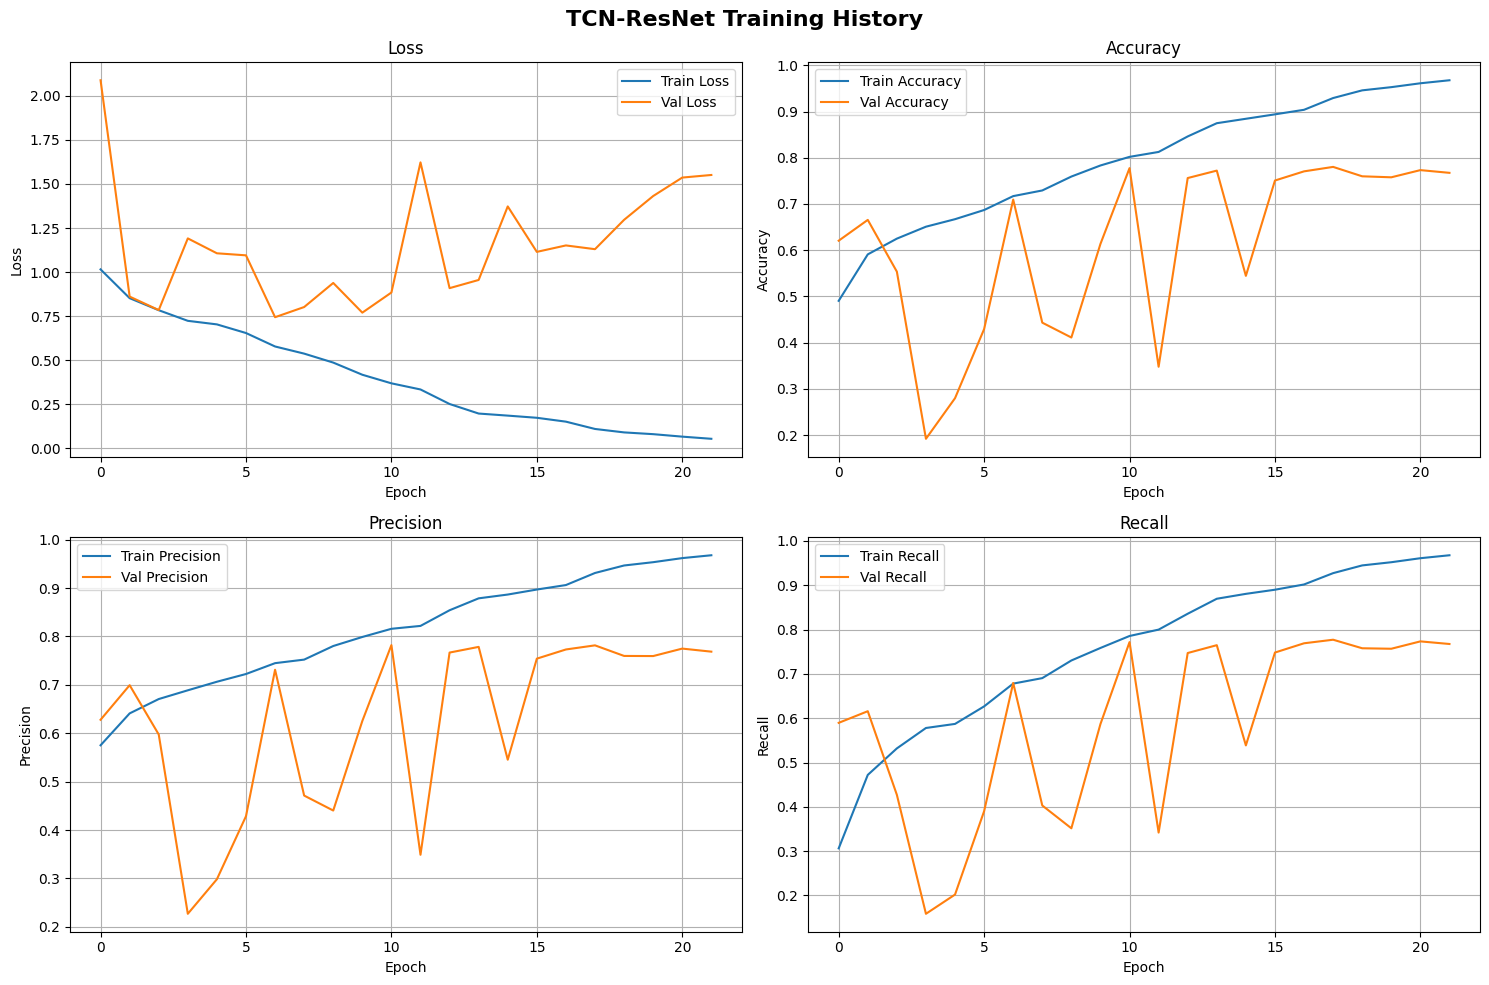

In [ ]:
def plot_training_history(history, title="Model Training History"):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Loss
    axes[0, 0].plot(history.history['loss'], label='Train Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
    axes[0, 0].set_title('Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Precision
    axes[1, 0].plot(history.history['precision'], label='Train Precision')
    axes[1, 0].plot(history.history['val_precision'], label='Val Precision')
    axes[1, 0].set_title('Precision')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Recall
    axes[1, 1].plot(history.history['recall'], label='Train Recall')
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall')
    axes[1, 1].set_title('Recall')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_training_history(history_combined, "TCN-ResNet Training History")


### Evaluate Combined Model


EVALUATING TCN-RESNET MODEL


2026-01-12 16:49:02.504451: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng11{k2=4,k3=0} for conv %cudnn-conv-bias-activation.87 = (f32[128,512,1,2250]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,512,1,2258]{3,2,1,0} %bitcast.3460, f32[512,512,1,9]{3,2,1,0} %bitcast.3464, f32[512]{0} %bitcast.3466), window={size=1x9}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="TCN_ResNet_1/TCN_Module_1/conv1d_19_1/convolution" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-01-12 16:49:02.663737: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.15939063s
Trying

59/59 ━━━━━━━━━━━━━━━━━━━━ 90s 598ms/step

Overall Metrics:
  Accuracy:  0.7095 (70.95%)
  Precision: 0.7415 (74.15%)
  Recall:    0.7095 (70.95%)
  F1 Score:  0.6757 (67.57%)

--------------------------------------------------
Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

  N (Normal)       0.76      0.93      0.84      1090
    A (AFib)       0.54      0.66      0.59       161
   O (Other)       0.80      0.26      0.40       556
   ~ (Noisy)       0.36      0.95      0.52        59

    accuracy                           0.71      1866
   macro avg       0.62      0.70      0.59      1866
weighted avg       0.74      0.71      0.68      1866



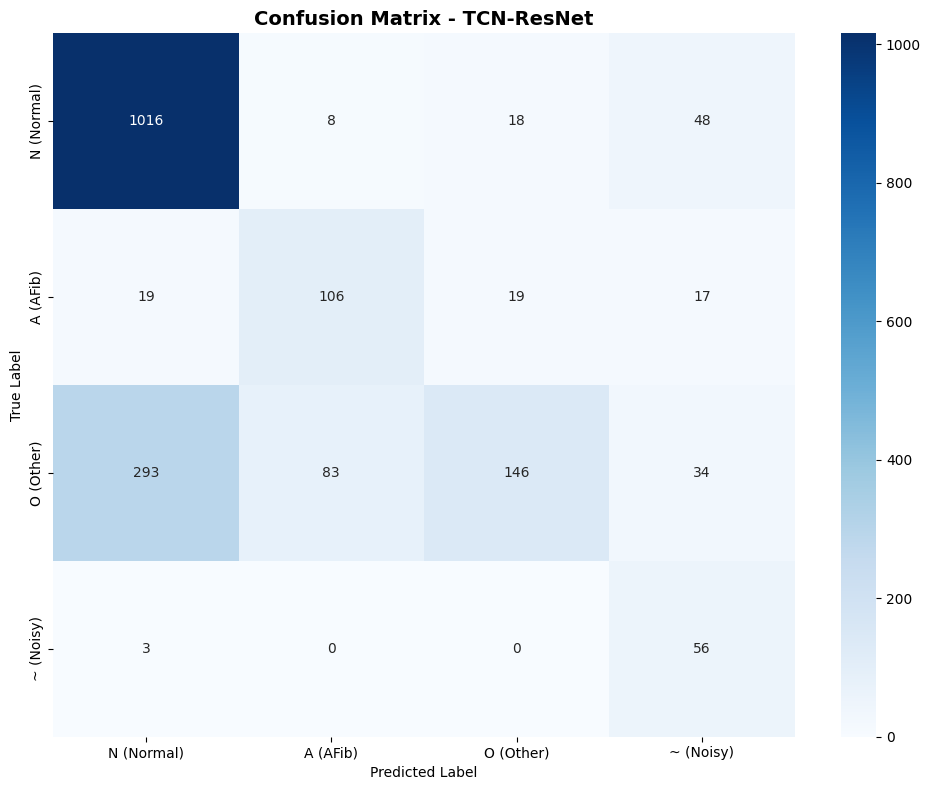

In [ ]:
print("\n" + "="*50)
print("EVALUATING TCN-RESNET MODEL")
print("="*50)

# Predictions
y_pred_proba = combined_model.predict([X_val, X_val_spec])
y_pred = np.argmax(y_pred_proba, axis=1)

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='weighted')
recall = recall_score(y_val, y_pred, average='weighted')
f1 = f1_score(y_val, y_pred, average='weighted')

print(f"\nOverall Metrics:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1 Score:  {f1:.4f} ({f1*100:.2f}%)")

# Per-class metrics
class_names = ['N (Normal)', 'A (AFib)', 'O (Other)', '~ (Noisy)']
print("\n" + "-"*50)
print("Classification Report:")
print("-"*50)
print(classification_report(y_val, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - TCN-ResNet', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Build and Train TCN-Only Model

In [ ]:
def build_tcn_only_model(input_shape=(9000, 1), num_classes=4):
    """Build TCN-only model"""
    inputs = layers.Input(shape=input_shape)

    # TCN module
    x = build_tcn_module(input_shape)(inputs)

    # Classification head
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='TCN_Only')
    return model

tcn_only_model = build_tcn_only_model()
tcn_only_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss=weighted_categorical_crossentropy(loss_weights),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("\n" + "="*50)
print("TRAINING TCN-ONLY MODEL")
print("="*50)

history_tcn = tcn_only_model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Evaluate TCN-only
y_pred_tcn = np.argmax(tcn_only_model.predict(X_val), axis=1)
acc_tcn = accuracy_score(y_val, y_pred_tcn)
f1_tcn = f1_score(y_val, y_pred_tcn, average='weighted')

print(f"\nTCN-Only Results:")
print(f"  Accuracy: {acc_tcn:.4f} ({acc_tcn*100:.2f}%)")
print(f"  F1 Score: {f1_tcn:.4f} ({f1_tcn*100:.2f}%)")


## Build and Train ResNet-Only Model

In [ ]:
def build_resnet_only_model(input_shape, num_classes=4):
    """Build ResNet-only model"""
    inputs = layers.Input(shape=input_shape)

    # ResNet module
    x = build_resnet_module(input_shape)(inputs)

    # Classification head
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='ResNet_Only')
    return model

resnet_only_model = build_resnet_only_model(X_train_spec.shape[1:])
resnet_only_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
    loss=weighted_categorical_crossentropy(loss_weights),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("TRAINING RESNET-ONLY MODEL")

history_resnet = resnet_only_model.fit(
    X_train_spec,
    y_train_cat,
    validation_data=(X_val_spec, y_val_cat),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Evaluate ResNet-only
y_pred_resnet = np.argmax(resnet_only_model.predict(X_val_spec), axis=1)
acc_resnet = accuracy_score(y_val, y_pred_resnet)
f1_resnet = f1_score(y_val, y_pred_resnet, average='weighted')

print(f"\nResNet-Only Results:")
print(f"  Accuracy: {acc_resnet:.4f} ({acc_resnet*100:.2f}%)")
print(f"  F1 Score: {f1_resnet:.4f} ({f1_resnet*100:.2f}%)")


In [ ]:
print("Model Comparison")

results_df = pd.DataFrame({
    'Model': ['TCN Only', 'ResNet Only', 'TCN + ResNet'],
    'Accuracy (%)': [acc_tcn*100, acc_resnet*100, accuracy*100],
    'Precision (%)': [
        precision_score(y_val, y_pred_tcn, average='weighted')*100,
        precision_score(y_val, y_pred_resnet, average='weighted')*100,
        precision*100
    ],
    'Recall (%)': [
        recall_score(y_val, y_pred_tcn, average='weighted')*100,
        recall_score(y_val, y_pred_resnet, average='weighted')*100,
        recall*100
    ],
    'F1 Score (%)': [f1_tcn*100, f1_resnet*100, f1*100]
})

print(results_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25

axes[0].bar(x - width, [acc_tcn*100, precision_score(y_val, y_pred_tcn, average='weighted')*100,
                         recall_score(y_val, y_pred_tcn, average='weighted')*100, f1_tcn*100],
            width, label='TCN Only')
axes[0].bar(x, [acc_resnet*100, precision_score(y_val, y_pred_resnet, average='weighted')*100,
                 recall_score(y_val, y_pred_resnet, average='weighted')*100, f1_resnet*100],
            width, label='ResNet Only')
axes[0].bar(x + width, [accuracy*100, precision*100, recall*100, f1*100],
            width, label='TCN + ResNet')

axes[0].set_ylabel('Score (%)')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Per-class F1 scores
class_f1_tcn = f1_score(y_val, y_pred_tcn, average=None)
class_f1_resnet = f1_score(y_val, y_pred_resnet, average=None)
class_f1_combined = f1_score(y_val, y_pred, average=None)

x2 = np.arange(len(class_names))
axes[1].bar(x2 - width, class_f1_tcn*100, width, label='TCN Only')
axes[1].bar(x2, class_f1_resnet*100, width, label='ResNet Only')
axes[1].bar(x2 + width, class_f1_combined*100, width, label='TCN + ResNet')

axes[1].set_ylabel('F1 Score (%)')
axes[1].set_title('Per-Class F1 Score Comparison')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()